In [2]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
import os
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover
import matplotlib

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
 
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/' # for latex, you might need to change this


#print(os.environ['PATH'])# = os.environ['PATH'] + 'c:/Library/TeX/texbin/' # for latex, you might need to change this
label_size = 8
# plt.style.use('fivethirtyeight')
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r'\usepackage{dsfont}\usepackage{amsmath}\usepackage{physics}')
#matplotlib.rcParams['text.latex.preamble']=[r'/usepackage{dsfont}/usepackage{amsmath}/usepackage{physics}']
 
pr ={"axes.labelsize": 8,               # LaTeX default is 10pt font.
     'axes.titlesize': 8,               
    "font.size": 8,
    "legend.fontsize": 8,               # Make the legend/label fonts
    "xtick.labelsize": 8,               # a little smaller
    "ytick.labelsize": 8,
    'figure.figsize': (1 * 3.35, 1.5* 9 * 3.35 / 16), #2.0476
    "errorbar.capsize": 1.5,
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots
    "font.sans-serif": [],    
    }
for k, v in pr.items():
    matplotlib.rcParams[k] = v
   
matplotlib.rcParams["font.family"] = "serif"
# mpl.rcParams["font.serif"] = ["STIX"]
matplotlib.rcParams["mathtext.fontset"] = "stix"


In [83]:
ns = range(100)
run = 2

In [3]:
def gurobi_solver(set, subsets):
    problem = qv_SetCover(set, subsets)
    Q = problem.to_qubo()
    size = problem.num_binary_variables
    matrix = np.zeros((size, size))
    for key, value in Q.items():
        if len(key)==0:
            pass
        elif len(key) == 1:
            matrix[key[0], key[0]] = value
        else:
            matrix[key[0], key[1]] = value

    result = solve_qubo(matrix)
    set_size = 0
    for i in range(len(subsets)):
        set_size += result.solution[i]
        
    return set_size

#### p=1

In [6]:
set_sizes = []
subset_sizes = []
shrinking_sizes = []
greedy_sizes = []
num_examples = 0

for n in ns: 
    with open(f'../data/results_node{n}_run_{run}.json') as f:
        data = json.load(f)
    
    for dic in data:
        set = dic["Set"]
        subsets = dic["Subsets"]
        shrinking_solution = dic["shrinking_solution"]
        problem = Generator.SetCover(set, subsets, A=2, B=1)   
        valid, rest_size = problem.solution_check(shrinking_solution)
        print(valid)
        
        #if valid:
        optimal_size = gurobi_solver(set, subsets)
        size = len(dic["Set"])
        size_shrinking = dic["shrinking_size"]
        size_greedy = dic['greedy_size']

        #corrected_shrinking_size = size_shrinking + rest_size

        set_sizes.append(size)
        subset_sizes.append(len(subsets))
        #for original size:
        shrinking_sizes.append(size_shrinking/optimal_size)

        #for corrected size:
        #shrinking_sizes.append(corrected_shrinking_size/optimal_size)

        greedy_sizes.append(size_greedy/optimal_size)
        num_examples +=1

True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -63.0
New QUBO solution found with objective -69.0
New QUBO solution found with objective -73.0
New QUBO solution found with objective -74.0
New QUBO solution found with objective -75.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -62.0
New QUBO solution found with objective -68.0
New QUBO solution found with objective -74.0
New QUBO solution found with objective -75.0
New QUBO solution found with objective -76.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -41.0
New QUBO solution found with objective -48.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -43.0
New QUBO solution found with objective -44.0
New QUBO solution found with objective -46.0
New QUBO solution found with objective -47.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -

In [76]:
num_examples

10000

In [ ]:
size_to_shrinking_values = defaultdict(list)
size_to_greedy_values = defaultdict(list)
subset_size_to_shrinking_values = defaultdict(list)

# Fill the dictionary with values corresponding to each size
for size, subset_size, shrinking_value, greedy_value in zip(set_sizes, subset_sizes, shrinking_sizes, greedy_sizes):
    size_to_shrinking_values[size].append(shrinking_value)
    subset_size_to_shrinking_values[size].append(subset_size)
    size_to_greedy_values[size].append(greedy_value)


# Initialize the lists for unique sizes and mean values
unique_sizes = []
mean_values_shrinking = []
std_values_shrinking = []
mean_subset_sizes = []
std_subset_sizes = []
mean_values_greedy = []
std_values_greedy = []

# Compute mean values for each unique size
for size in size_to_shrinking_values:
    print(size, len(size_to_shrinking_values[size]))
    unique_sizes.append(size)
    mean_values_shrinking.append(np.mean(size_to_shrinking_values[size]))
    std_values_shrinking.append(np.std(size_to_shrinking_values[size]))

for size in subset_size_to_shrinking_values:
    mean_subset_sizes.append(np.mean(subset_size_to_shrinking_values[size]))
    std_subset_sizes.append(np.std(subset_size_to_shrinking_values[size]))


# Compute mean values for each unique size
for size in size_to_greedy_values:
    mean_values_greedy.append(np.mean(size_to_greedy_values[size]))
    std_values_greedy.append(np.std(size_to_greedy_values[size]))

# for size in unique_sizes:
#     print("\nsize")
#     print('shrinking', len(size_to_shrinking_values[size]))
#     print('greedy', len(size_to_greedy_values[size]))



list_to_sort_by = unique_sizes
zipped_lists = zip(list_to_sort_by, unique_sizes, mean_values_shrinking, std_values_shrinking, mean_values_greedy, std_values_greedy, mean_subset_sizes, std_subset_sizes)
sorted_zipped_lists = sorted(zipped_lists, key = lambda x: x[0])
_, sorted_unique_sizes, sorted_mean_values_shrinking, sorted_std_values_shrinking, sorted_mean_values_greedy, sorted_std_values_greedy, sorted_mean_subset_sizes, sorted_std_subset_sizes = zip(*sorted_zipped_lists)
sorted_unique_sizes = list(sorted_unique_sizes)
sorted_mean_values_shrinking = list(sorted_mean_values_shrinking)
sorted_mean_values_greedy = list(sorted_mean_values_greedy)
sorted_std_values_shrinking = list(sorted_std_values_shrinking)
sorted_std_values_greedy = list(sorted_std_values_greedy)
sorted_mean_subset_sizes = list(sorted_mean_subset_sizes)
sorted_std_subset_sizes = list(sorted_std_subset_sizes)


In [8]:
sorted_mean_values_greedy.pop()
sorted_mean_values_greedy.pop()

sorted_mean_values_shrinking.pop()
sorted_mean_values_shrinking.pop()

sorted_std_values_greedy.pop()
sorted_std_values_greedy.pop()

sorted_std_values_shrinking.pop()
sorted_std_values_shrinking.pop()

sorted_unique_sizes.pop()
sorted_unique_sizes.pop()

60

#### p=2


In [96]:
set_sizes_p2 = []
shrinking_sizes_p2 = []
greedy_sizes_p2 = []
num_examples_p2 = 0
idxs = range(100)

for n in ns: 
    for idx in idxs:
        try: 
            with open(f'../data/results_node{n}_run_{run}_idx_{idx}p_2.json', 'r') as f:
                dic = json.loads(f.read())
            
            print('a')
            set = dic["Set"]
            subsets = dic["Subsets"]
            shrinking_solution = dic["shrinking_solution"]
            problem = Generator.SetCover(set, subsets, A=2, B=1)   
            valid, rest_size = problem.solution_check(shrinking_solution)
            print(valid)
            
            #if valid:
            optimal_size = gurobi_solver(set, subsets)
            size = len(dic["Set"])
            size_shrinking = dic["shrinking_size"]

            #corrected_shrinking_size = size_shrinking + rest_size

            set_sizes_p2.append(size)
            print(size)
            #for original size:
            shrinking_sizes_p2.append(size_shrinking/optimal_size)

            #for corrected size:
            #shrinking_sizes.append(corrected_shrinking_size/optimal_size)
            num_examples_p2 +=1
        except Exception as error:
            #print(error)
            pass

a
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -5.0
4


In [97]:
print(num_examples_p2)

1


In [98]:
size_to_shrinking_values_p2 = defaultdict(list)

# Fill the dictionary with values corresponding to each size
for size, shrinking_value in zip(set_sizes_p2, shrinking_sizes_p2):
    size_to_shrinking_values_p2[size].append(shrinking_value)

# Initialize the lists for unique sizes and mean values
unique_sizes_p2 = []
mean_values_shrinking_p2 = []
std_values_shrinking_p2 = []

# Compute mean values for each unique size
for size in size_to_shrinking_values_p2:
    print(size, len(size_to_shrinking_values_p2[size]))
    unique_sizes_p2.append(size)
    mean_values_shrinking_p2.append(np.mean(size_to_shrinking_values_p2[size]))
    std_values_shrinking_p2.append(np.std(size_to_shrinking_values_p2[size]))

# for size in unique_sizes:
#     print("\nsize")
#     print('shrinking', len(size_to_shrinking_values[size]))
#     print('greedy', len(size_to_greedy_values[size]))

list_to_sort_by_p2 = unique_sizes_p2
zipped_lists_p2 = zip(list_to_sort_by_p2, unique_sizes_p2, mean_values_shrinking_p2, std_values_shrinking_p2)
sorted_zipped_lists_p2 = sorted(zipped_lists_p2, key = lambda x: x[0])
_, sorted_unique_sizes_p2, sorted_mean_values_shrinking_p2, sorted_std_values_shrinking_p2 = zip(*sorted_zipped_lists_p2)
sorted_unique_sizes_p2 = list(sorted_unique_sizes_p2)
sorted_mean_values_shrinking_p2 = list(sorted_mean_values_shrinking_p2)
sorted_std_values_shrinking_p2 = list(sorted_std_values_shrinking_p2)


4 1


### All valid solutions

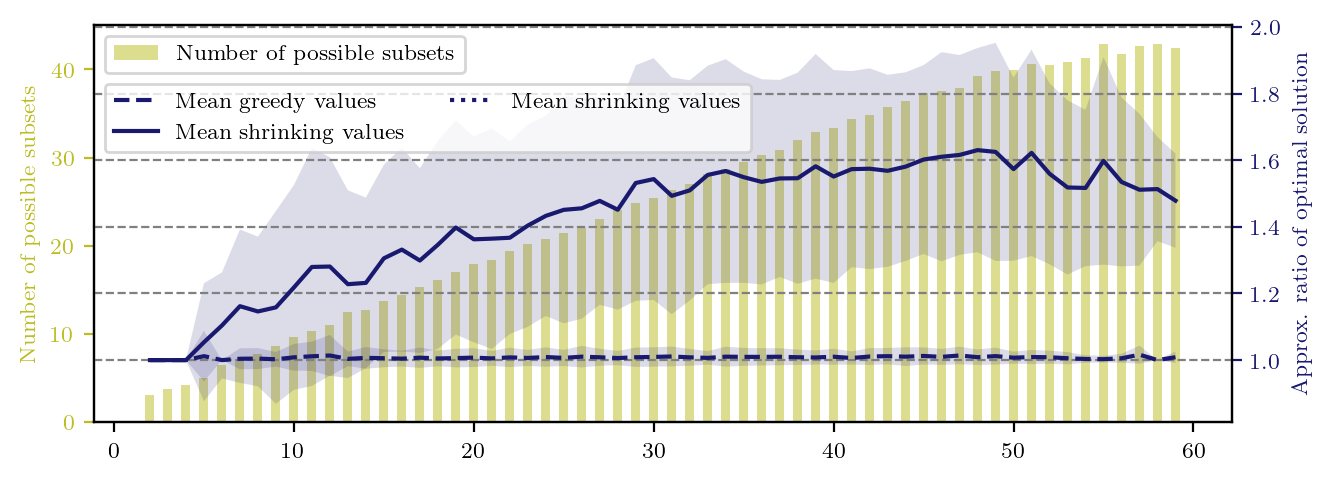

In [100]:
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'midnightblue', 'tab:olive', 'tab:grey','tab:brown', 'tab:cyan']
fig, ax1 = plt.subplots(1, 1, dpi=200, figsize=(2 * 3.35, 1.3* 9 * 3.35 / 16))

ax2 = ax1.twinx()
ax1.set_ylabel('Number of possible subsets', color=colors[7])
handle = ax1.bar(sorted_unique_sizes, sorted_mean_subset_sizes, width = 0.5, label = 'Number of subsets', color = colors[7], alpha = 0.5)


upper_bound = [i + j for i, j in zip(sorted_mean_values_greedy, sorted_std_values_greedy)]
lower_bound = [i - j for i, j in zip(sorted_mean_values_greedy, sorted_std_values_greedy )]
ax2.fill_between(sorted_unique_sizes, lower_bound, upper_bound, alpha = 0.15, color = colors[6], edgecolor = None)

upper_bound = [i + j for i, j in zip(sorted_mean_values_shrinking, sorted_std_values_shrinking)]
lower_bound = [i - j for i, j in zip(sorted_mean_values_shrinking, sorted_std_values_shrinking)]
ax2.fill_between(sorted_unique_sizes, lower_bound, upper_bound, alpha = 0.15, color = colors[6], edgecolor = None)

upper_bound = [i + j for i, j in zip(sorted_mean_values_shrinking_p2, sorted_std_values_shrinking_p2)]
lower_bound = [i - j for i, j in zip(sorted_mean_values_shrinking_p2, sorted_std_values_shrinking_p2)]
ax2.fill_between(sorted_unique_sizes_p2, lower_bound, upper_bound, alpha = 0.15, color = colors[6], edgecolor = None)

ax2.plot(sorted_unique_sizes, sorted_mean_values_greedy, linestyle= '--', color=colors[6], label='Mean greedy values')

ax2.plot(sorted_unique_sizes, sorted_mean_values_shrinking, linestyle='solid', color=colors[6], label='Mean shrinking values')

ax2.plot(sorted_unique_sizes_p2, sorted_mean_values_shrinking_p2, linestyle='dotted', color=colors[6], label='Mean shrinking values')


ax2.yaxis.grid(color='gray', linestyle='dashed')
ax2.xaxis.grid(color='gray', linestyle='dashed')
# Adding labels and title


ax2.set_xlabel('Size of set to cover')
ax2.set_ylabel('Approx. ratio of optimal solution', color = colors[6])
ax2.tick_params(axis='y', colors = colors[6])
ax1.tick_params(axis='y', colors = colors[7])

ax2.legend(loc = 'upper left', ncols=2, bbox_to_anchor=(0, 0.88))

ax1.legend([handle], ['Number of possible subsets'], loc = 'upper left', ncols=1, bbox_to_anchor=(0, 1))



fig.tight_layout()
# Show the plot
plt.show()

### All corrected solutions

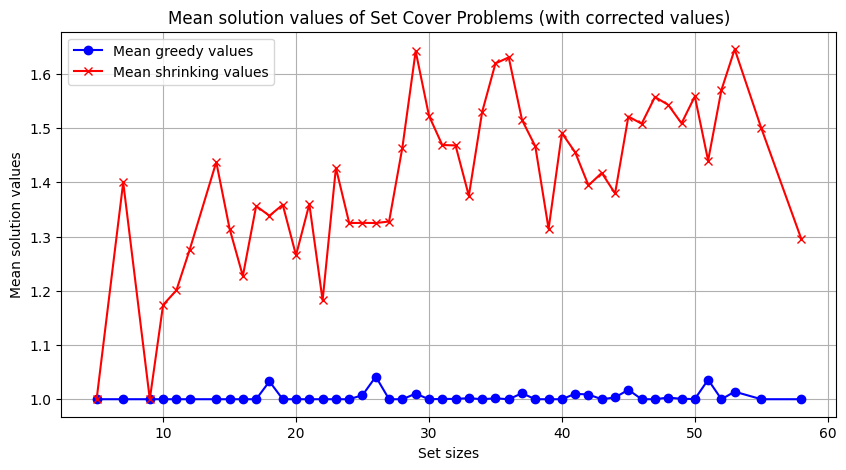

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(sorted_unique_sizes, sorted_mean_values_greedy, marker='o', linestyle='-', color='b', label='Mean greedy values')
plt.plot(sorted_unique_sizes, sorted_mean_values_shrinking, marker='x', linestyle='-', color='r', label='Mean shrinking values')


# Adding labels and title
plt.xlabel('Set sizes')
plt.ylabel('Mean solution values')
plt.title('Mean solution values of Set Cover Problems (with corrected values)')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()